# Probe baseline — Classificação de Baltimore a partir de embeddings do EVO2 7B

**Pergunta:** os embeddings do `evo2_7b` (modelo **base, sem fine-tuning**) já codificam o **tipo de genoma viral** (classe de Baltimore: dsDNA, ssDNA, dsRNA, ssRNA+, ssRNA−, retro)?

**Estratégia:** para cada genoma do corpus V1 RefSeq → 1 embedding (mean-pool dos tokens, camada intermediária) → treinar um classificador linear `embedding → classe de Baltimore` e medir acurácia / F1. É o **baseline** contra o qual o modelo fine-tunado será comparado depois (ver `06_evo2_inference/BASELINE_EMBEDDING_PROBES.md`).

**Corpus:** `s3://<YOUR_S3_BUCKET>/corpus/raw/v1_refseq/` (19.429 genomas).

---
*Notebook para rodar no Space SageMaker (`ml.g6e.xlarge`, 1×L4 48 GB, imagem evo2 v2).*

## Pré-requisitos

1. **Kernel:** imagem **evo2 v2** (traz `evo2`, `torch`, CUDA). L4 (24 GB) comporta o 7B em bf16 (~14 GB de pesos).
2. **Acesso S3:** a role do Space precisa de **leitura** em `s3://<YOUR_S3_BUCKET>/corpus/*` (baixa manifesto + features + FASTA).
3. **Pesos:** `Evo2('evo2_7b')` baixa de HuggingFace na 1ª vez (precisa de internet) ou reutiliza pesos já locais.

> Ajuste o bloco **CONFIG** e rode as células em ordem.

In [1]:
# ============================ CONFIG ============================
BUCKET        = "<YOUR_S3_BUCKET>"
MANIFEST_KEY  = "corpus/raw/v1_refseq/composed/composition_manifest.parquet"  # accession -> baltimore, host, quota_group
FEATURES_KEY  = "corpus/raw/v1_refseq/features/genome_features.parquet"       # accession -> GC, genome_length, coding_fraction, ...
FASTA_KEY     = "corpus/raw/v1_refseq/fasta/all_genomes.fasta"
LOCAL_DIR     = "/home/<USER>/evo2_probe"

MODEL_NAME    = "evo2_7b"
LAYER_NAME    = "blocks.28.mlp.l3"   # camada de embedding (ver BASELINE_EMBEDDING_PROBES.md)
DEVICE        = "cuda:0"

WINDOW        = 32768    # tamanho do contexto/janela (tokens = bp); evo2_7b-1m suporta contextos longos
STRIDE        = 16384    # passo entre janelas (overlap 50%) p/ genomas > WINDOW
MAX_WINDOWS   = 8        # teto de janelas por genoma (limita custo em genomas gigantes)
N_PER_CLASS   = 150      # genomas amostrados por classe (balanceamento)
MIN_CLASS     = 40       # descarta classes menores que isto
SEED          = 42

EMB_CACHE     = f"{LOCAL_DIR}/embeddings_baltimore_{MODEL_NAME}_w{WINDOW}.npz"
import os; os.makedirs(LOCAL_DIR, exist_ok=True)
print("config OK ·", MODEL_NAME, "· camada", LAYER_NAME, "· WINDOW", WINDOW, "· MAX_WINDOWS", MAX_WINDOWS)

config OK · evo2_7b · camada blocks.28.mlp.l3 · WINDOW 32768 · MAX_WINDOWS 8


In [2]:
# ============================ SETUP ============================
import sys, subprocess
def pip(*pkgs): subprocess.run([sys.executable,"-m","pip","install","-q",*pkgs], check=False)
pip("scikit-learn","matplotlib","seaborn","pandas","pyarrow","boto3","tqdm")

import numpy as np, pandas as pd, torch
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    cc = torch.cuda.get_device_capability(0)
    print(f"GPU: {p.name} | {p.total_memory/1e9:.1f} GB | compute capability {cc[0]}.{cc[1]}")
else:
    print("⚠️  Sem GPU — o EVO2 7B precisa de GPU.")

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.3-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 25.1 w

torch 2.7.0a0+79aa17489c.nv25.04 | CUDA: True
GPU: NVIDIA L40S | 47.8 GB | compute capability 8.9


## 1. Carregar o corpus do S3

Baixa **manifesto** (rótulo `baltimore`), **features** (`GC`, `genome_length`, `coding_fraction`… — usados no controle) e o **FASTA**. Faz o merge e monta um subset balanceado por classe.

In [3]:
import boto3, os
s3 = boto3.client("s3")
paths = {}
for key in [MANIFEST_KEY, FEATURES_KEY, FASTA_KEY]:
    dst = f"{LOCAL_DIR}/{os.path.basename(key)}"; paths[key] = dst
    if os.path.exists(dst) and os.path.getsize(dst) > 0:
        print("cache:", dst); continue
    print("baixando", key); s3.download_file(BUCKET, key, dst)
print("ok · FASTA", round(os.path.getsize(paths[FASTA_KEY])/1e6,1), "MB")

cache: /home/<USER>/evo2_probe/composition_manifest.parquet
cache: /home/<USER>/evo2_probe/genome_features.parquet
cache: /home/<USER>/evo2_probe/all_genomes.fasta
ok · FASTA 578.5 MB


In [4]:
# Merge manifesto + features (por accession)
BALT_NAMES = {"I":"I dsDNA","II":"II ssDNA","III":"III dsRNA",
              "IV":"IV ssRNA(+)","V":"V ssRNA(-)","VI":"VI ssRNA-RT","VII":"VII dsDNA-RT"}
man  = pd.read_parquet(paths[MANIFEST_KEY])
feat = pd.read_parquet(paths[FEATURES_KEY])
feat_cols = [c for c in ["accession","GC","genome_length","coding_fraction","gene_density","n_genes","n_CDS"] if c in feat.columns]
man  = man.merge(feat[feat_cols], on="accession", how="left")
print("genomas:", len(man), "| colunas:", list(man.columns))
print("\nclasses de Baltimore (cru):")
print(man["baltimore"].value_counts(dropna=False).to_string())

genomas: 19429 | colunas: ['accession', 'family', 'genus', 'baltimore', 'host', 'quota_group', 'is_recent', 'length', 'GC', 'genome_length', 'coding_fraction', 'gene_density', 'n_genes', 'n_CDS']

classes de Baltimore (cru):
baltimore
I      6311
IV     3549
?      3238
II     2432
V      2005
III    1663
VII     137
VI       94


In [5]:
# Subset: classes conhecidas, filtro de tamanho, amostragem balanceada
rng = np.random.default_rng(SEED)
df = man[man["baltimore"].isin(BALT_NAMES)].copy()   # janelamento cobre genomas de qualquer tamanho
counts = df["baltimore"].value_counts()
keep   = counts[counts >= MIN_CLASS].index.tolist()
df     = df[df["baltimore"].isin(keep)]
subset = (df.groupby("baltimore", group_keys=False)
            .apply(lambda g: g.sample(min(N_PER_CLASS, len(g)), random_state=SEED))
            .reset_index(drop=True))
print(f"subset: {len(subset)} genomas | WINDOW={WINDOW} STRIDE={STRIDE} MAX_WINDOWS={MAX_WINDOWS}\n")
for b in sorted(subset["baltimore"].unique()):
    print(f"  {BALT_NAMES[b]:14s}: {(subset.baltimore==b).sum()}")
subset[["accession","baltimore","family","length","GC","coding_fraction"]].head()

subset: 981 genomas | WINDOW=32768 STRIDE=16384 MAX_WINDOWS=8

  I dsDNA       : 150
  II ssDNA      : 150
  III dsRNA     : 150
  IV ssRNA(+)   : 150
  V ssRNA(-)    : 150
  VI ssRNA-RT   : 94
  VII dsDNA-RT  : 137


/tmp/ipykernel_151/2290343374.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(N_PER_CLASS, len(g)), random_state=SEED))


,accession,baltimore,family,length,GC,coding_fraction
0,NC_108593.1,I,Salasmaviridae,20678,35.057,0.8947
1,NC_052980.1,I,Casjensviridae,59078,46.720,0.9126
2,NC_038522.1,I,Papillomaviridae,7238,37.731,0.9239
3,NC_044939.1,I,Ascoviridae,199721,45.845,0.8689
4,NC_008152.1,I,Autosignataviridae,44385,45.247,0.9177


In [6]:
# Carrega as sequências do subset (parser FASTA streaming, sem biopython)
wanted = set(subset["accession"]); seqs = {}; acc, buf = None, []
def flush():
    if acc is not None and acc in wanted: seqs[acc] = "".join(buf)
with open(paths[FASTA_KEY]) as fh:
    for ln in fh:
        if ln.startswith(">"):
            flush(); acc = ln[1:].split()[0]; buf = []
        else: buf.append(ln.strip())
flush()
subset = subset[subset["accession"].isin(seqs)].reset_index(drop=True)
print(f"sequências carregadas: {len(seqs)} | subset final: {len(subset)}")

sequências carregadas: 981 | subset final: 981


## 2. Carregar o EVO2 7B (base, sem fine-tuning)

### ⚙️ Compatibilidade L4/A10G/A100 — desligar FP8 sem editar `site-packages`

O `evo2_7b` pode ser usado fora de H100 em **bfloat16**, mas algumas configs vêm com `use_fp8_input_projections: true`. Em GPUs não-Hopper como **L4**, **A10G** e **A100**, esse caminho pode falhar com erro de FP8/Transformer Engine.

Como o pacote instalado em SageMaker normalmente fica em `/usr/local/lib/.../site-packages` sem permissão de escrita, a célula abaixo **não edita o YAML original**. Ela cria uma cópia local auditável em `~/evo2_configs/` e faz um monkey patch em `evo2.models.pkgutil.get_data` para que, quando o Evo2 pedir o YAML original, receba a versão com `use_fp8_input_projections=False`.

Rode esta célula **antes** de `Evo2(MODEL_NAME)`. Se você já tentou carregar o modelo antes, reinicie o kernel e rode o notebook novamente em ordem.


In [7]:
# ============================ EVO2 7B PATCH: FP8 OFF EM GPU NÃO-HOPPER ============================
# Motivo: SageMaker Space geralmente não permite escrever em /usr/local/lib/.../site-packages.
# Além disso, o Evo2 lê a config via pkgutil.get_data(...), então apontar CONFIG_MAP para um
# caminho absoluto em ~/ pode não funcionar. Em vez disso, interceptamos a leitura da config.

import os, yaml, evo2
import evo2.models as evo2_models

# Não redefina MODEL_NAME aqui: usamos o valor definido na célula CONFIG.
assert MODEL_NAME in evo2_models.CONFIG_MAP, f"MODEL_NAME inválido: {MODEL_NAME}"

cfg_resource = evo2_models.CONFIG_MAP[MODEL_NAME]  # ex.: configs/evo2-7b-1m.yml
print("MODEL_NAME:", MODEL_NAME)
print("Config resource original:", cfg_resource)

# Lê a config original como o próprio Evo2 faria.
cfg_bytes = evo2_models.pkgutil.get_data(evo2_models.__name__, cfg_resource)
if cfg_bytes is None:
    raise FileNotFoundError(f"Não consegui ler a config do Evo2: {cfg_resource}")

cfg = yaml.safe_load(cfg_bytes)
print("use_fp8_input_projections antes:", cfg.get("use_fp8_input_projections"))

# Desliga FP8 para rodar em A10G/L4/A100.
cfg["use_fp8_input_projections"] = False
patched_cfg_bytes = yaml.safe_dump(cfg, sort_keys=False).encode("utf-8")

# Salva uma cópia local para auditoria/debug, mas o Evo2 continuará recebendo o conteúdo via pkgutil.
local_cfg_dir = os.path.expanduser("~/evo2_configs")
os.makedirs(local_cfg_dir, exist_ok=True)
local_cfg_path = os.path.join(local_cfg_dir, os.path.basename(cfg_resource))
with open(local_cfg_path, "wb") as f:
    f.write(patched_cfg_bytes)

# Guarda o get_data original uma única vez, para permitir reexecutar esta célula sem empilhar patches.
if not hasattr(evo2_models, "_original_pkgutil_get_data"):
    evo2_models._original_pkgutil_get_data = evo2_models.pkgutil.get_data

_original_get_data = evo2_models._original_pkgutil_get_data

def _patched_get_data(package, resource):
    # Evo2 chama pkgutil.get_data(__name__, config_path), onde __name__ == "evo2.models".
    if package == evo2_models.__name__ and resource == cfg_resource:
        return patched_cfg_bytes
    return _original_get_data(package, resource)

# Patch no namespace usado por evo2.models.load_evo2_model.
evo2_models.pkgutil.get_data = _patched_get_data

# Mantém CONFIG_MAP apontando para o resource original do pacote.
# Importante: não usar caminho absoluto aqui, porque load_evo2_model chama pkgutil.get_data.
evo2_models.CONFIG_MAP[MODEL_NAME] = cfg_resource

# Validação: lê novamente pelo caminho que o construtor do Evo2 usará.
validated = yaml.safe_load(evo2_models.pkgutil.get_data(evo2_models.__name__, cfg_resource))
print("use_fp8_input_projections depois:", validated.get("use_fp8_input_projections"))
print("Cópia local auditável:", local_cfg_path)
print("Patch aplicado no get_data:", evo2_models.pkgutil.get_data.__name__)


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MODEL_NAME: evo2_7b
Config resource original: configs/evo2-7b-1m.yml
use_fp8_input_projections antes: True
use_fp8_input_projections depois: False
Cópia local auditável: /home/<USER>/evo2_configs/evo2-7b-1m.yml
Patch aplicado no get_data: _patched_get_data


In [8]:
# ============================ CARREGAR EVO2 ============================
import gc, torch, traceback

# Se já existir um modelo parcialmente carregado, libera CPU/VRAM antes de tentar de novo.
try:
    del model
except NameError:
    pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

from evo2 import Evo2

try:
    model = Evo2(MODEL_NAME)  # agora constrói em bf16, sem FP8 nas input projections
    model.model.eval()
except Exception as e:
    print("\n❌ Falha ao carregar o Evo2")
    print("Tipo:", type(e).__name__)
    print("Mensagem:", str(e))
    print("\nDicas rápidas:")
    print("1) Se aparecer FP8 / Transformer Engine / Float8Tensor: reinicie o kernel e rode a célula de patch antes desta.")
    print("2) Se aparecer CUDA out of memory: tente ml.g6e.* / L40S 48 GB ou reduza contexto/checkpoint.")
    print("3) Se aparecer flash_attn / undefined symbol / CUDA extension: é incompatibilidade de ambiente CUDA/PyTorch/flash-attn.")
    raise

print("modelo carregado:", MODEL_NAME)
if torch.cuda.is_available():
    print(f"VRAM alocada: {torch.cuda.memory_allocated()/1e9:.1f} GB")
    print(f"Pico de VRAM: {torch.cuda.max_memory_allocated()/1e9:.1f} GB")


GPU: NVIDIA L40S
VRAM total: 47.8 GB


[06/13/26 14:17:09] INFO     httpx - INFO - HTTP Request: GET                                       ]8;id=817965;file:///usr/local/lib/python3.12/dist-packages/httpx/_client.py\_client.py]8;;\:]8;id=438278;file:///usr/local/lib/python3.12/dist-packages/httpx/_client.py#1025\1025]8;;\
                             https://huggingface.co/api/models/arcinstitute/evo2_7b/revision/main                  
                             "HTTP/1.1 200 OK"                                                                     

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

                    INFO     httpx - INFO - HTTP Request: HEAD                                      ]8;id=332181;file:///usr/local/lib/python3.12/dist-packages/httpx/_client.py\_client.py]8;;\:]8;id=220243;file:///usr/local/lib/python3.12/dist-packages/httpx/_client.py#1025\1025]8;;\
                             https://huggingface.co/arcinstitute/evo2_7b/resolve/bda0089f92582d5baa                
                             bf0f22d9fc85f3588f6b58/README.md "HTTP/1.1 307 Temporary Redirect"                    

                    INFO     httpx - INFO - HTTP Request: HEAD                                      ]8;id=829758;file:///usr/local/lib/python3.12/dist-packages/httpx/_client.py\_client.py]8;;\:]8;id=602431;file:///usr/local/lib/python3.12/dist-packages/httpx/_client.py#1025\1025]8;;\
                             https://huggingface.co/api/resolve-cache/models/arcinstitute/evo2_7b/b                
                             da0089f92582d5baabf0f22d9fc85f3588f6b58/README.md "HTTP/1.1 200 OK"                   

...

                    INFO     StripedHyena - INFO - Initialized model                                   ]8;id=539564;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py\model.py]8;;\:]8;id=974950;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py#691\691]8;;\

                    INFO     vortex.model.utils - INFO - Loading                                        ]8;id=625726;file:///usr/local/lib/python3.12/dist-packages/vortex/model/utils.py\utils.py]8;;\:]8;id=556965;file:///usr/local/lib/python3.12/dist-packages/vortex/model/utils.py#92\92]8;;\
                             /home/<USER>/.cache/huggingface/hub/models--arcinstitute--evo2_7b/snapshot            
                             s/bda0089f92582d5baabf0f22d9fc85f3588f6b58/evo2_7b.pt                                 

Extra keys in state_dict: {'blocks.24.mixer.attn._extra_state', 'blocks.30.mixer.mixer.filter.t', 'blocks.3.mixer.dense._extra_state', 'blocks.24.mixer.dense._extra_state', 'blocks.17.mixer.dense._extra_state', 'blocks.3.mixer.attn._extra_state', 'blocks.27.mixer.mixer.filter.t', 'blocks.31.mixer.dense._extra_state', 'blocks.6.mixer.mixer.filter.t', 'blocks.17.mixer.attn._extra_state', 'blocks.10.mixer.dense._extra_state', 'blocks.16.mixer.mixer.filter.t', 'blocks.9.mixer.mixer.filter.t', 'blocks.2.mixer.mixer.filter.t', 'unembed.weight', 'blocks.31.mixer.attn._extra_state', 'blocks.10.mixer.attn._extra_state', 'blocks.20.mixer.mixer.filter.t', 'blocks.23.mixer.mixer.filter.t', 'blocks.13.mixer.mixer.filter.t'}


[06/13/26 14:17:54] INFO     StripedHyena - INFO - Adjusting Wqkv for column split (permuting rows)    ]8;id=851922;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py\model.py]8;;\:]8;id=875202;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py#976\976]8;;\

modelo carregado: evo2_7b
VRAM alocada: 13.2 GB
Pico de VRAM: 13.7 GB


## 3. Extrair embeddings (com janelamento)

Por genoma: divide em janelas de `WINDOW` (tokens=bp) com passo `STRIDE`; **genoma ≤ WINDOW = 1 janela** (genoma inteiro num forward só). Cada janela → forward na camada `LAYER_NAME` → **mean-pool dos tokens**; depois **mean-pool das janelas** → 1 vetor por genoma. `MAX_WINDOWS` limita o custo em genomas gigantes (subamostra janelas ao longo do genoma). Cache em `.npz` (nome inclui `WINDOW`, então mudar a janela recomputa).

In [9]:
from tqdm.auto import tqdm

def make_windows(seq):
    "Genoma <= WINDOW -> 1 janela (genoma inteiro). Maior -> janelas WINDOW/STRIDE, com teto MAX_WINDOWS."
    L = len(seq)
    if L <= WINDOW:
        return [seq]
    starts = list(range(0, L - WINDOW + 1, STRIDE))
    if starts[-1] != L - WINDOW:
        starts.append(L - WINDOW)                       # garante cobrir o final do genoma
    if len(starts) > MAX_WINDOWS:                        # subamostra janelas uniformes ao longo do genoma
        idx = np.linspace(0, len(starts) - 1, MAX_WINDOWS).round().astype(int)
        starts = sorted(set(starts[j] for j in idx))
    return [seq[s:s + WINDOW] for s in starts]

@torch.inference_mode()
def embed_sequence(seq):
    seq = seq.upper()
    vecs = []
    for w in make_windows(seq):
        ids = torch.tensor(model.tokenizer.tokenize(w), dtype=torch.int).unsqueeze(0).to(DEVICE)
        _, emb = model(ids, return_embeddings=True, layer_names=[LAYER_NAME])
        vecs.append(emb[LAYER_NAME].float().mean(dim=1).squeeze(0).cpu().numpy())   # mean-pool dos tokens
        del ids, emb
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    return np.mean(vecs, axis=0)                          # mean-pool das janelas -> 1 vetor/genoma

if os.path.exists(EMB_CACHE):
    d = np.load(EMB_CACHE, allow_pickle=True); X, y, accs = d["X"], d["y"], d["accs"]
    print("embeddings do cache:", X.shape)
else:
    X, y, accs = [], [], []
    for i, row in enumerate(tqdm(subset.itertuples(index=False), total=len(subset))):
        try:
            X.append(embed_sequence(seqs[row.accession])); y.append(row.baltimore); accs.append(row.accession)
        except Exception as e:
            print("falhou", row.accession, "->", repr(e))
    X = np.vstack(X); y = np.array(y); accs = np.array(accs)
    np.savez_compressed(EMB_CACHE, X=X, y=y, accs=accs); print("salvo:", EMB_CACHE)
print("X:", X.shape, "| classes:", sorted(set(y.tolist())))

  0%|          | 0/981 [00:00<?, ?it/s]

[06/13/26 14:17:55] INFO     vortex.model.utils - INFO - Fixup applied: Allocating cublas workspace    ]8;id=697769;file:///usr/local/lib/python3.12/dist-packages/vortex/model/utils.py\utils.py]8;;\:]8;id=47187;file:///usr/local/lib/python3.12/dist-packages/vortex/model/utils.py#191\191]8;;\
                             for device=0                                                                          

100%|██████████| 981/981 [58:37<00:00,  3.59s/it]  


salvo: /home/<USER>/evo2_probe/embeddings_baltimore_evo2_7b_w32768.npz
X: (981, 4096) | classes: ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII']


## 4. Probe — classificação de Baltimore

Regressão logística multinomial sobre embeddings padronizados, validação cruzada estratificada 5-fold.

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced"))
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_pred = cross_val_predict(clf, X, y, cv=cv)

acc = accuracy_score(y, y_pred); f1m = f1_score(y, y_pred, average="macro")
labels = sorted(set(y.tolist()))
print(f"Acurácia (5-fold CV): {acc:.3f}\nF1-macro            : {f1m:.3f}\n")
print(classification_report(y, y_pred, labels=labels,
      target_names=[BALT_NAMES[b] for b in labels], zero_division=0))

Acurácia (5-fold CV): 0.891
F1-macro            : 0.895

              precision    recall  f1-score   support

     I dsDNA       0.92      0.94      0.93       150
    II ssDNA       0.93      0.89      0.91       150
   III dsRNA       0.82      0.81      0.82       150
 IV ssRNA(+)       0.81      0.81      0.81       150
  V ssRNA(-)       0.87      0.87      0.87       150
 VI ssRNA-RT       0.97      0.95      0.96        94
VII dsDNA-RT       0.94      0.99      0.96       137

    accuracy                           0.89       981
   macro avg       0.90      0.90      0.90       981
weighted avg       0.89      0.89      0.89       981



[06/13/26 15:19:25] INFO     matplotlib.font_manager - INFO - generated new fontManager        ]8;id=258957;file:///usr/local/lib/python3.12/dist-packages/matplotlib/font_manager.py\font_manager.py]8;;\:]8;id=108252;file:///usr/local/lib/python3.12/dist-packages/matplotlib/font_manager.py#1639\1639]8;;\

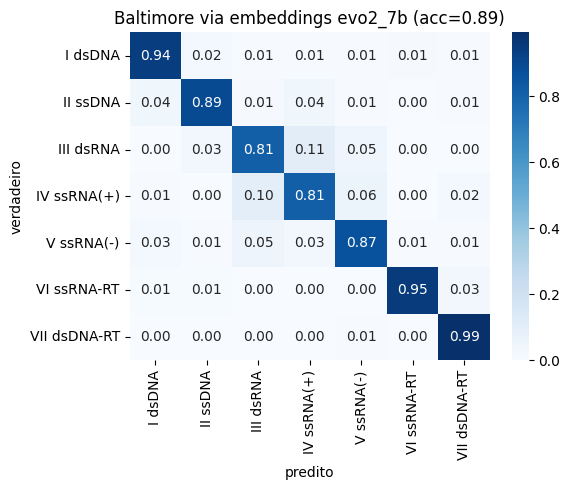

In [11]:
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, y_pred, labels=labels, normalize="true")
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[BALT_NAMES[b] for b in labels], yticklabels=[BALT_NAMES[b] for b in labels])
plt.xlabel("predito"); plt.ylabel("verdadeiro")
plt.title(f"Baltimore via embeddings {MODEL_NAME} (acc={acc:.2f})")
plt.tight_layout(); plt.show()

### Controle: o embedding ganha de sinais triviais?

`GC` e `genome_length` sozinhos já separam parte das classes. Comparamos o classificador de **embeddings** com um de **só GC + length** — o ganho mostra que o EVO2 codifica algo além do óbvio (§2.2 do BASELINE_EMBEDDING_PROBES).

In [12]:
feat_aligned = subset.set_index("accession").loc[list(accs)]
Xtriv = feat_aligned[["GC","genome_length"]].fillna(0).values
triv  = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
yp_triv = cross_val_predict(triv, Xtriv, y, cv=cv)
acc_triv = accuracy_score(y, yp_triv)
print(f"Acurácia só GC+length : {acc_triv:.3f}")
print(f"Acurácia embeddings   : {acc:.3f}")
print(f"Ganho do embedding    : {acc-acc_triv:+.3f}")

Acurácia só GC+length : 0.388
Acurácia embeddings   : 0.891
Ganho do embedding    : +0.503


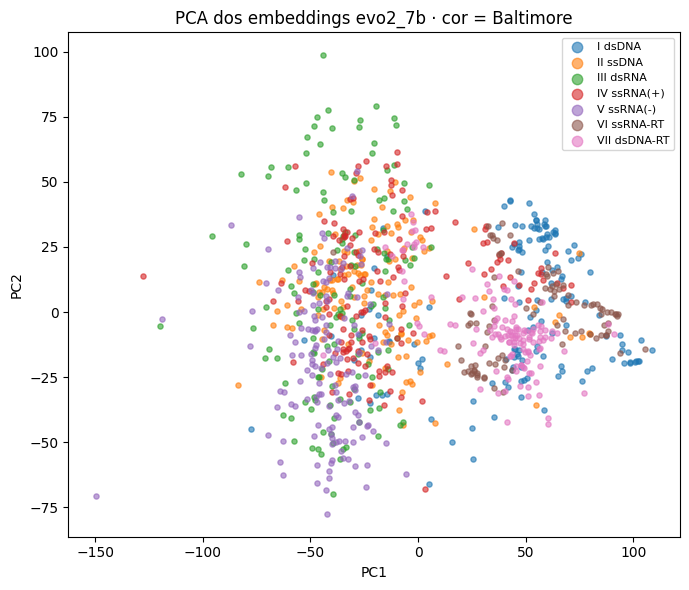

In [13]:
# Geometria: PCA 2D dos embeddings, cor = Baltimore
from sklearn.decomposition import PCA
Z = PCA(n_components=2, random_state=SEED).fit_transform(StandardScaler().fit_transform(X))
plt.figure(figsize=(7,6))
for b in labels:
    m = (y==b); plt.scatter(Z[m,0], Z[m,1], s=14, alpha=.6, label=BALT_NAMES[b])
plt.legend(markerscale=2, fontsize=8); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"PCA dos embeddings {MODEL_NAME} · cor = Baltimore")
plt.tight_layout(); plt.show()

## Interpretação e próximos passos

- **Acurácia alta + ganho positivo sobre GC+length** → o EVO2 base já codifica o tipo de genoma viral.
- **Confusões** (ex.: ssRNA+ × ssRNA−) apontam onde a representação é mais fraca — candidatas a melhorar com o FT V1.

**Extensões (mesmo pipeline, trocando o alvo `y`):**
1. **Regressão** `embedding → coding_fraction / gene_density / n_genes` (R² com controle length+GC).
2. **Classificação de `host`** (eucarioto/bactéria/archaea) e de `family`.
3. **Baseline × fine-tuned** (V1 RefSeq → V2): ΔAcurácia / ΔR² por feature — o entregável que valida o FT.

Embeddings cacheados em `EMB_CACHE` (`.npz`), reutilizáveis sem recomputar.